# SHAP Explanations & Monitoring — Week 6

Model explainability is critical for trust and debugging. This notebook:

1. **SHAP summary plot** — which features matter most globally?
2. **SHAP force plots** — why did the model make *this specific* prediction?
3. **SHAP dependence plots** — how does ELO difference affect predictions?
4. **Monitoring** — run predictions on recent matches and track accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path

sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()

FEATURE_COLS = [
    "home_elo", "away_elo", "elo_diff", "elo_prob",
    "home_form_5", "away_form_5", "home_form_10", "away_form_10",
    "home_avg_margin_5", "away_avg_margin_5",
    "home_avg_score_5", "away_avg_score_5",
    "home_avg_conceded_5", "away_avg_conceded_5",
    "home_streak", "away_streak",
    "h2h_home_wins_5", "h2h_avg_margin_5",
    "home_venue_win_rate", "away_venue_win_rate",
    "round_number",
]

print("Setup complete.")

Setup complete.


## 1. Load Data & Models

In [2]:
features = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "features.csv", parse_dates=["date"])
df = features.dropna(subset=FEATURE_COLS + ["home_win", "margin"])

train = df[df["season"] < 2024]
test = df[df["season"] >= 2024]

X_train = train[FEATURE_COLS]
y_train = train["home_win"].astype(int)
X_test = test[FEATURE_COLS]
y_test = test["home_win"].astype(int)

models_dir = PROJECT_ROOT / "models" / "saved"
xgb_clf = joblib.load(models_dir / "xgb_classifier.joblib")
lgbm_clf = joblib.load(models_dir / "lgbm_classifier.joblib")

print(f"Train: {len(train)} | Test: {len(test)}")
print(f"Models loaded.")

Train: 1447 | Test: 397
Models loaded.


## 2. Compute SHAP Values

TreeSHAP is an efficient algorithm for computing exact SHAP values for tree-based models (XGBoost, LightGBM). It runs in polynomial time rather than the exponential time needed for the general SHAP algorithm.

We compute SHAP values for the entire test set so we can analyze patterns globally.

In [3]:
import warnings

# Create SHAP explainers for both models
xgb_explainer = shap.TreeExplainer(xgb_clf)
lgbm_explainer = shap.TreeExplainer(lgbm_clf, model_output="raw")

# Compute SHAP values on test set
xgb_shap_values = xgb_explainer.shap_values(X_test)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="LightGBM binary classifier")
    lgbm_shap_values = lgbm_explainer.shap_values(X_test)

# Handle case where shap_values returns list (one per class)
if isinstance(xgb_shap_values, list):
    xgb_shap_values = xgb_shap_values[1]  # positive class (home win)
if isinstance(lgbm_shap_values, list):
    lgbm_shap_values = lgbm_shap_values[1]

# Average SHAP values from both models (mirrors ensemble logic)
ensemble_shap = (xgb_shap_values + lgbm_shap_values) / 2

print(f"SHAP values computed for {len(X_test)} test games.")
print(f"Shape: {ensemble_shap.shape} (games x features)")

SHAP values computed for 397 test games.
Shape: (397, 21) (games x features)


## 3. SHAP Summary Plot — Global Feature Importance

The summary plot shows which features have the biggest impact **across all predictions**. Each dot is one game. Position on x-axis = SHAP value (how much it pushed the prediction). Color = feature value (red = high, blue = low).

**How to read it:** If `elo_diff` dots are spread far from zero, it means ELO difference strongly influences predictions. Red dots on the right = high ELO difference pushes toward home win.

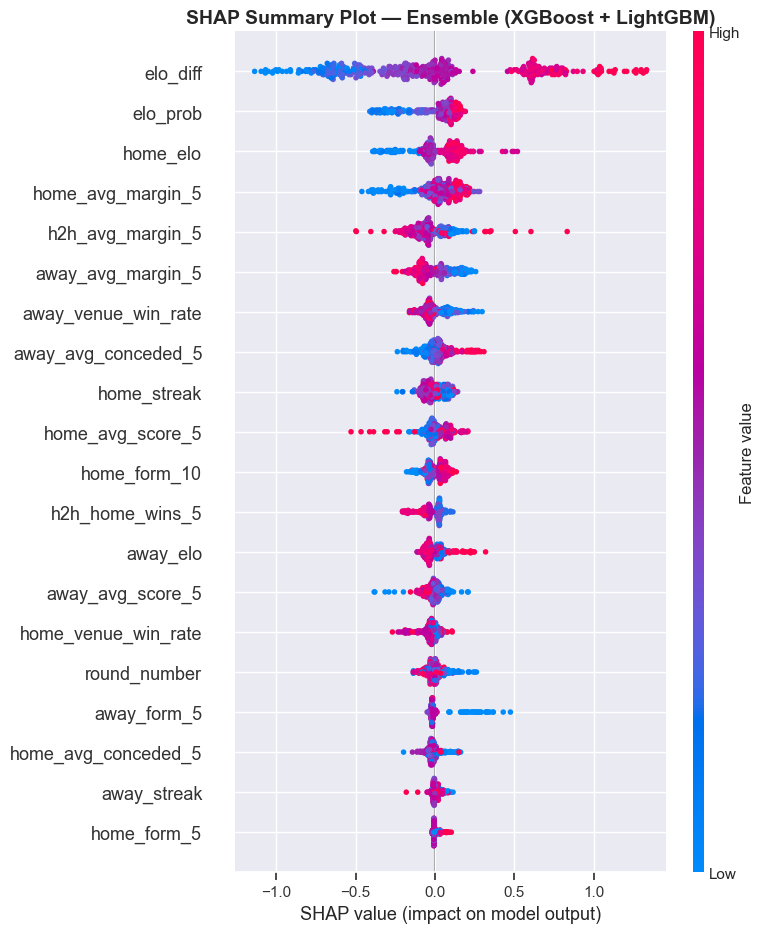

Each dot = one game. X-axis = how much that feature pushed the prediction.
Red = high feature value, Blue = low feature value.
Features sorted by mean absolute SHAP value (most important at top).


In [4]:
# SHAP summary plot — beeswarm (all features, all test games)
plt.figure(figsize=(12, 8))
shap.summary_plot(ensemble_shap, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Summary Plot — Ensemble (XGBoost + LightGBM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Each dot = one game. X-axis = how much that feature pushed the prediction.")
print("Red = high feature value, Blue = low feature value.")
print("Features sorted by mean absolute SHAP value (most important at top).")

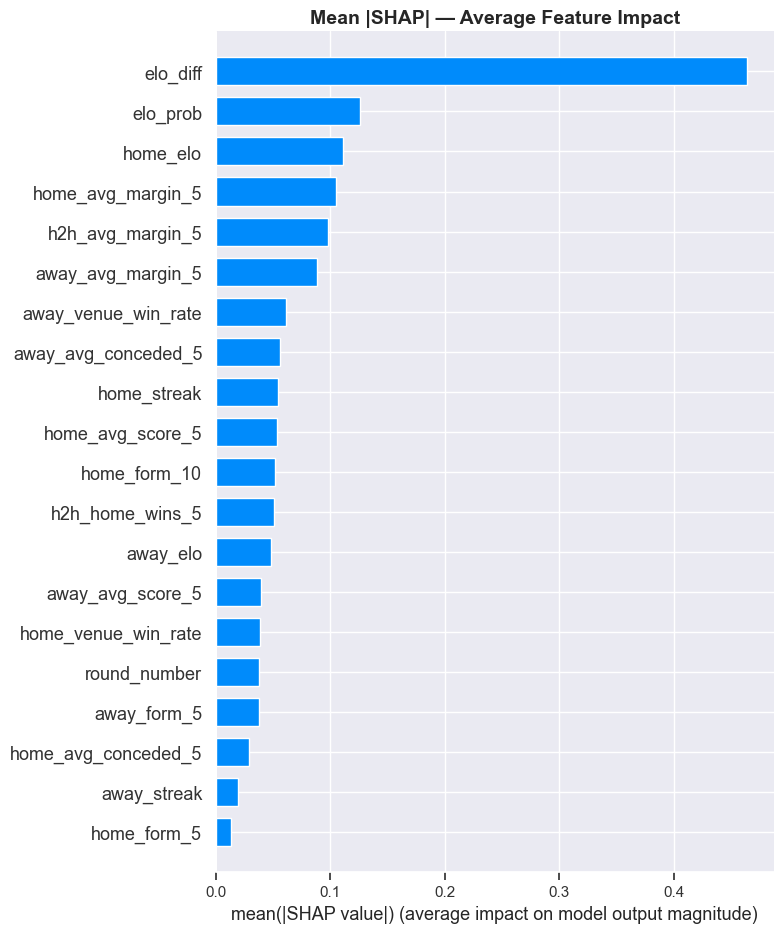

Top 5 features by mean |SHAP|:
                   elo_diff: 0.4646
                   elo_prob: 0.1265
                   home_elo: 0.1115
          home_avg_margin_5: 0.1055
           h2h_avg_margin_5: 0.0983


In [5]:
# Bar plot — mean absolute SHAP value per feature (cleaner view)
plt.figure(figsize=(12, 6))
shap.summary_plot(ensemble_shap, X_test, feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.title("Mean |SHAP| — Average Feature Impact", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top 5
mean_abs_shap = np.abs(ensemble_shap).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:5]
print("Top 5 features by mean |SHAP|:")
for i in top_idx:
    print(f"  {FEATURE_COLS[i]:>25s}: {mean_abs_shap[i]:.4f}")

## 4. SHAP Force Plots — Individual Predictions

Force plots show exactly how each feature contributed to ONE specific prediction. The base value (average prediction) is pushed up or down by each feature.

We'll look at three interesting cases:
1. A **confident correct** prediction
2. A **confident wrong** prediction (upset)
3. A **close call** (near 50/50)

In [6]:
# Generate ensemble predictions to find interesting cases
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_clf.predict_proba(X_test)[:, 1]
ensemble_probs = (xgb_probs + lgbm_probs) / 2
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

analysis = test.copy().reset_index(drop=True)
analysis["prob"] = ensemble_probs
analysis["predicted"] = ensemble_preds
analysis["correct"] = (analysis["predicted"] == analysis["home_win"].astype(int))
analysis["confidence"] = abs(analysis["prob"] - 0.5)

# Find examples
confident_correct = analysis[analysis["correct"] & (analysis["confidence"] > 0.2)].iloc[0]
confident_wrong = analysis[~analysis["correct"]].sort_values("confidence", ascending=False).iloc[0]
close_call = analysis.sort_values("confidence").iloc[0]

print("=== Selected Games for Force Plots ===\n")
for label, game in [("Confident Correct", confident_correct),
                     ("Confident Wrong (Upset)", confident_wrong),
                     ("Close Call", close_call)]:
    pred = "Home" if game["predicted"] == 1 else "Away"
    actual = "Home" if game["home_win"] == 1 else "Away"
    print(f"{label}:")
    print(f"  {game['home_team']} vs {game['away_team']} at {game['venue']}")
    print(f"  Predicted: {pred} ({game['prob']:.0%}) | Actual: {actual}")
    print()

=== Selected Games for Force Plots ===

Confident Correct:
  Carlton vs Richmond at M.C.G.
  Predicted: Home (77%) | Actual: Home

Confident Wrong (Upset):
  Richmond vs Gold Coast at Docklands
  Predicted: Away (15%) | Actual: Home

Close Call:
  Essendon vs St Kilda at Docklands
  Predicted: Away (50%) | Actual: Home



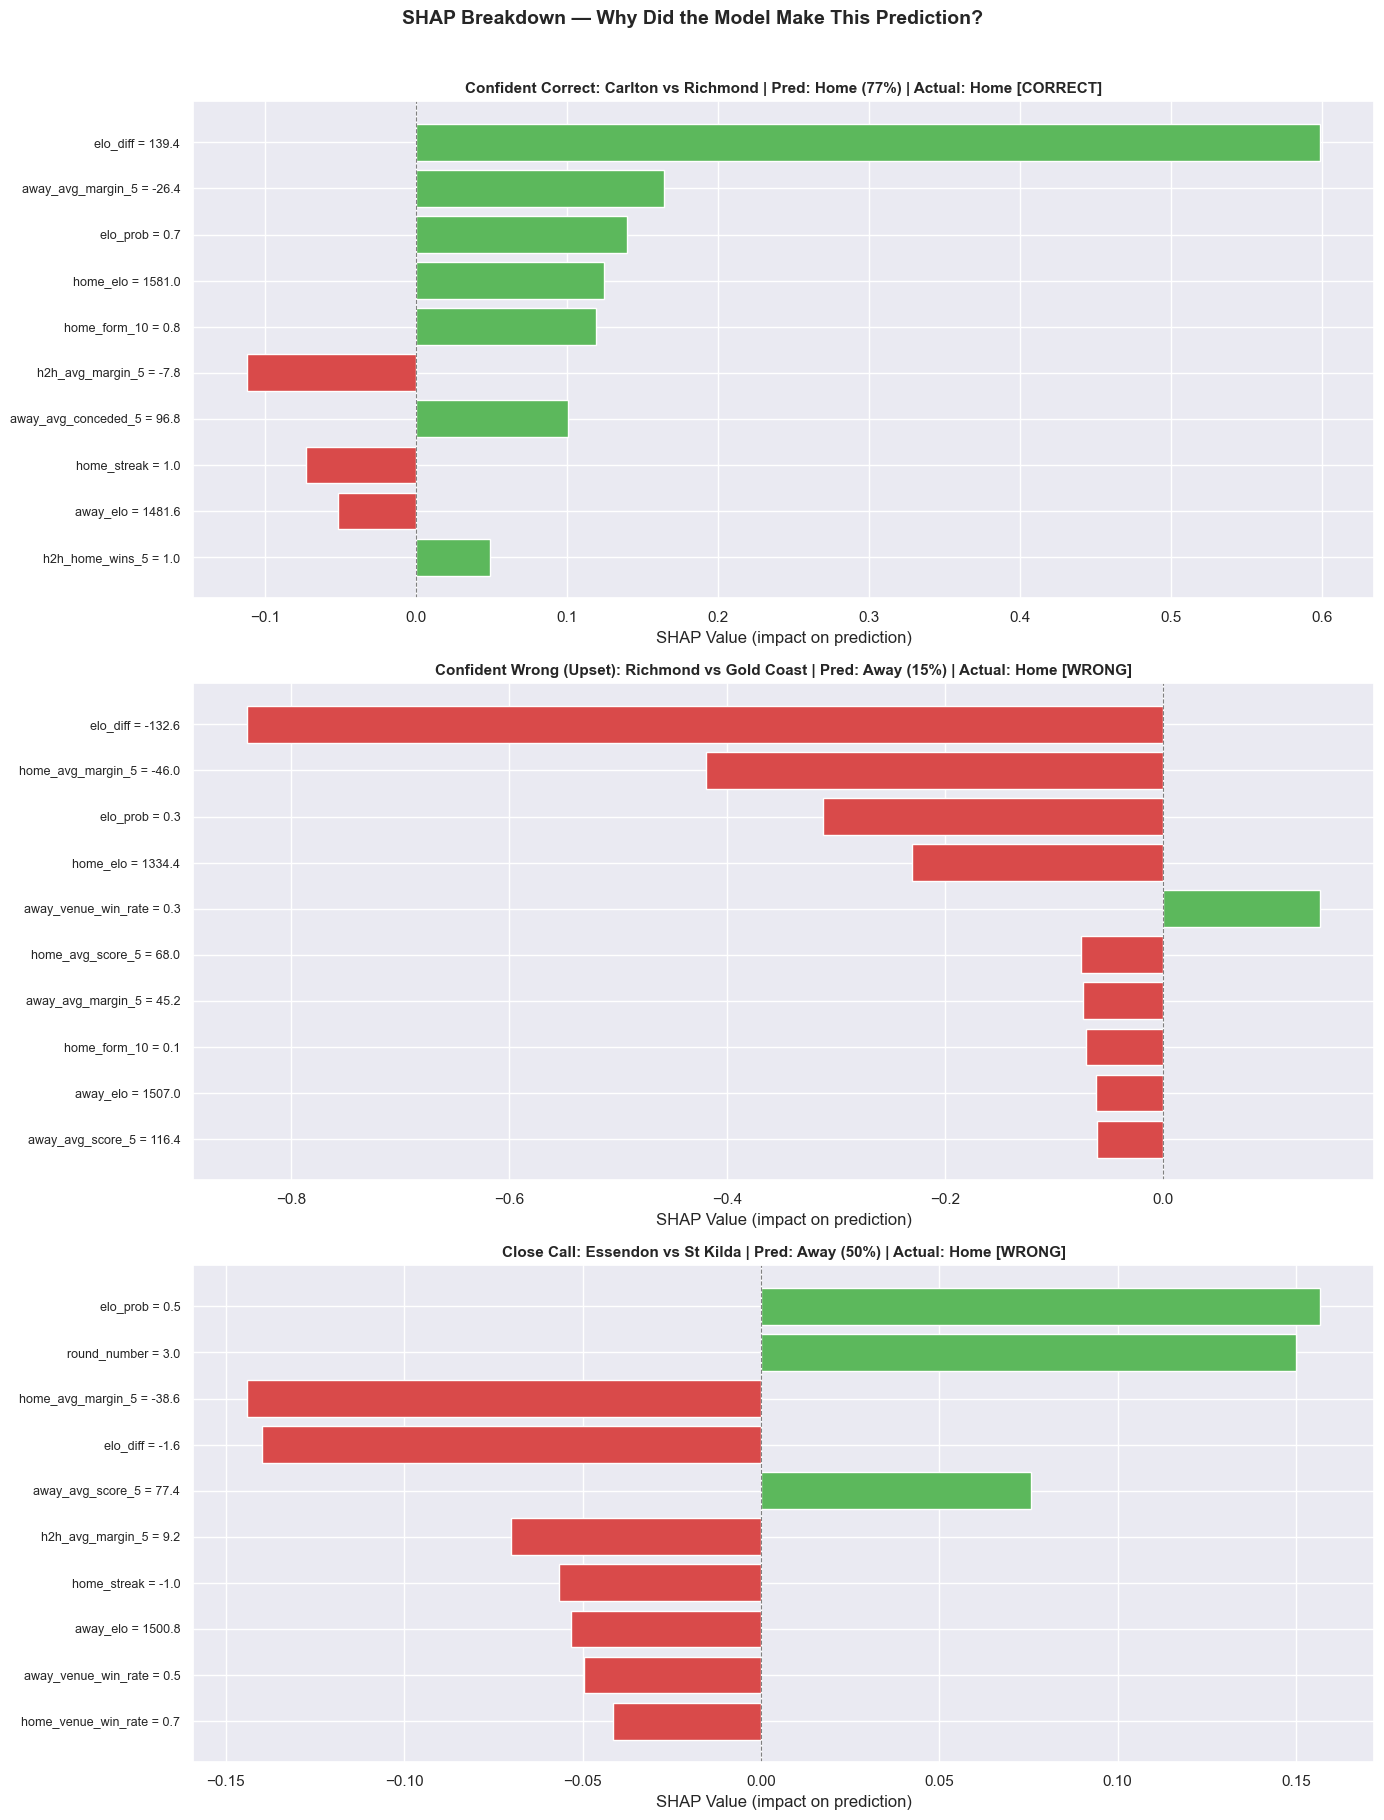

Green bars push toward home win. Red bars push toward away win.
Feature values shown on the y-axis labels.


In [7]:
# Waterfall plots — clearer than force plots for static notebooks
shap.initjs()

base_value = xgb_explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

cases = [
    ("Confident Correct", confident_correct),
    ("Confident Wrong (Upset)", confident_wrong),
    ("Close Call", close_call),
]

for idx, (label, game) in enumerate(cases):
    game_idx = game.name  # index in the reset test set
    shap_vals = ensemble_shap[game_idx]

    # Sort by absolute value
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:10]  # top 10

    features_sorted = [FEATURE_COLS[i] for i in sorted_idx]
    values_sorted = [shap_vals[i] for i in sorted_idx]
    feat_values = [X_test.iloc[game_idx, i] for i in sorted_idx]

    colors = ["#d94a4a" if v < 0 else "#5cb85c" for v in values_sorted]

    axes[idx].barh(range(len(features_sorted)), values_sorted, color=colors, edgecolor="white")
    axes[idx].set_yticks(range(len(features_sorted)))
    axes[idx].set_yticklabels([f"{f} = {v:.1f}" for f, v in zip(features_sorted, feat_values)], fontsize=9)
    axes[idx].invert_yaxis()
    axes[idx].axvline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[idx].set_xlabel("SHAP Value (impact on prediction)")

    pred = "Home" if game["predicted"] == 1 else "Away"
    actual = "Home" if game["home_win"] == 1 else "Away"
    result = "CORRECT" if game["correct"] else "WRONG"
    axes[idx].set_title(
        f"{label}: {game['home_team']} vs {game['away_team']} | "
        f"Pred: {pred} ({game['prob']:.0%}) | Actual: {actual} [{result}]",
        fontsize=11, fontweight="bold"
    )

plt.suptitle("SHAP Breakdown — Why Did the Model Make This Prediction?",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Green bars push toward home win. Red bars push toward away win.")
print("Feature values shown on the y-axis labels.")

## 5. SHAP Dependence Plots

Dependence plots show the relationship between a single feature's value and its SHAP impact. This reveals **non-linear** patterns the model has learned.

For example: does the model treat a +50 ELO advantage the same as a +200 ELO advantage? (It shouldn't — bigger gaps should matter more.)

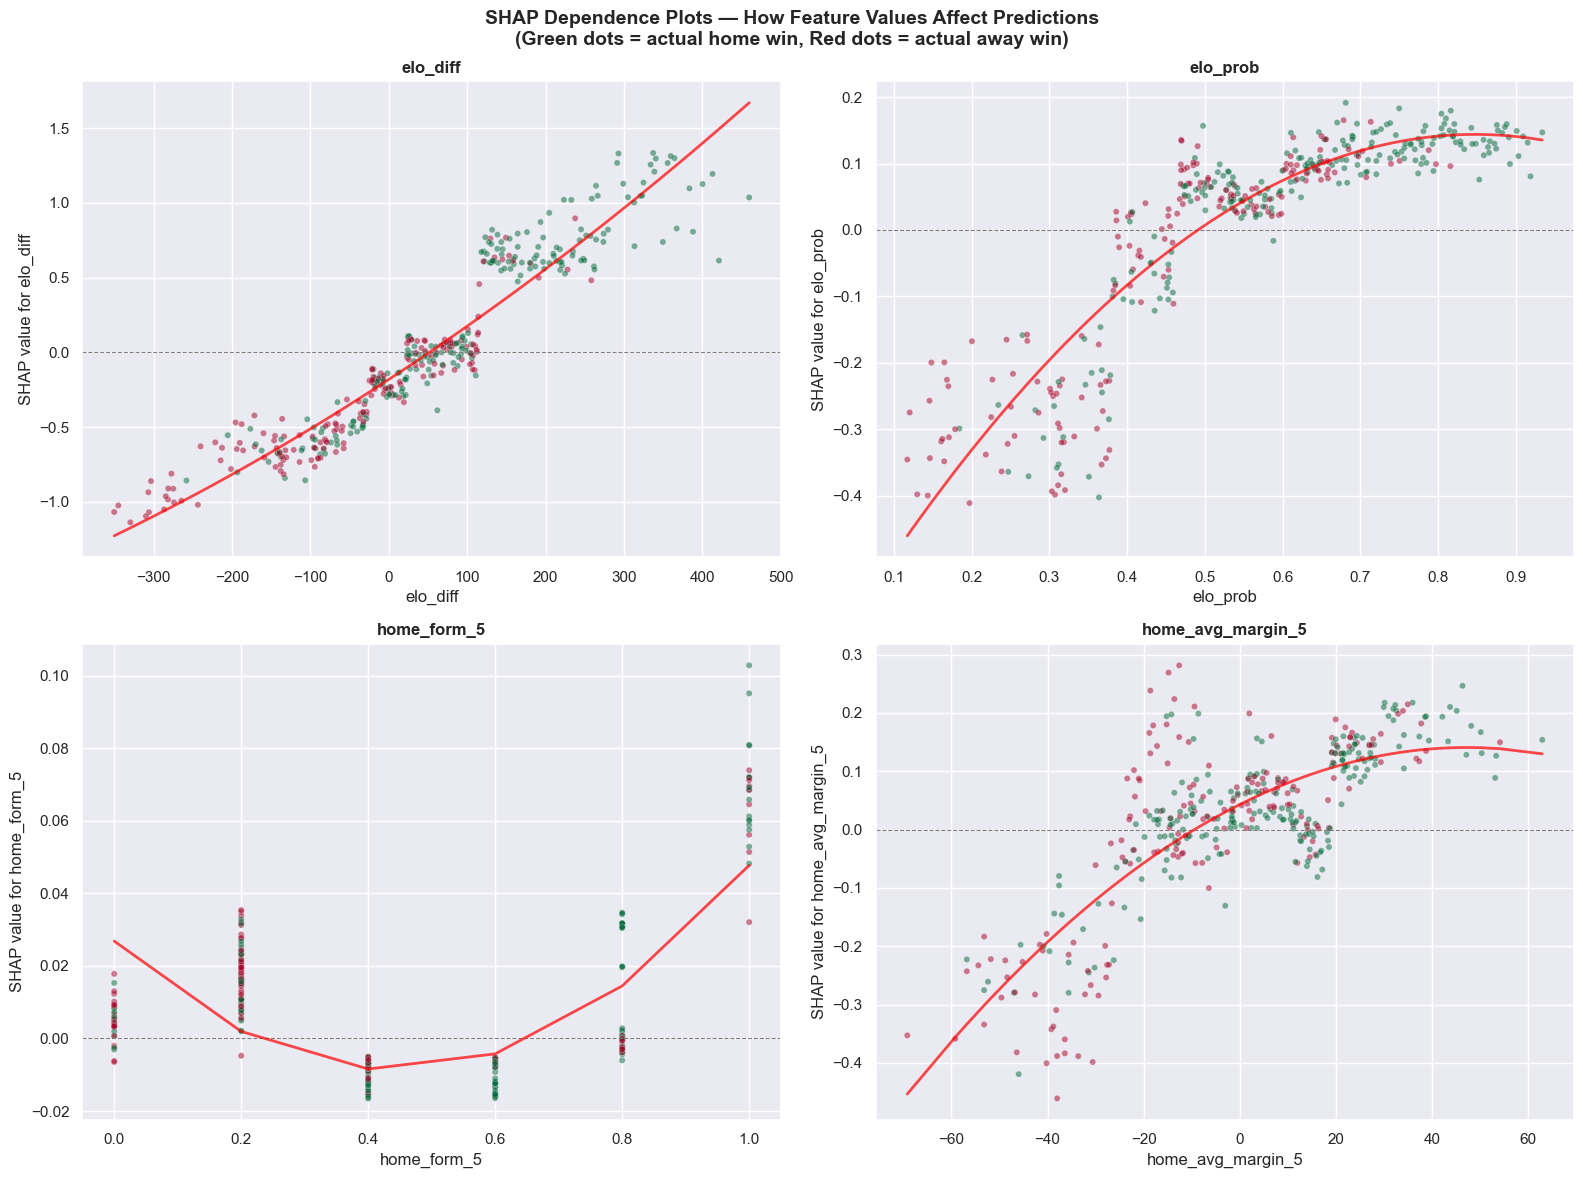

The red trend line shows the average relationship.
Steeper curves = the feature has a stronger non-linear effect.
Scatter = the model considers interactions (not just this feature alone).


In [8]:
# Dependence plots for top 4 features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

dep_features = ["elo_diff", "elo_prob", "home_form_5", "home_avg_margin_5"]

for ax, feat in zip(axes.ravel(), dep_features):
    feat_idx = FEATURE_COLS.index(feat)
    feat_vals = X_test[feat].values
    shap_vals = ensemble_shap[:, feat_idx]

    scatter = ax.scatter(feat_vals, shap_vals, c=y_test.values, cmap="RdYlGn",
                         alpha=0.5, s=20, edgecolors="white", linewidth=0.3)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel(f"SHAP value for {feat}")
    ax.set_title(feat, fontsize=12, fontweight="bold")

    # Add trend line
    z = np.polyfit(feat_vals, shap_vals, 2)
    p = np.poly1d(z)
    x_sorted = np.sort(feat_vals)
    ax.plot(x_sorted, p(x_sorted), color="red", linewidth=2, alpha=0.7)

plt.suptitle("SHAP Dependence Plots — How Feature Values Affect Predictions\n"
             "(Green dots = actual home win, Red dots = actual away win)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("The red trend line shows the average relationship.")
print("Steeper curves = the feature has a stronger non-linear effect.")
print("Scatter = the model considers interactions (not just this feature alone).")

## 6. SHAP Interaction Effects

Do features work together? For example, does ELO difference matter more when a team is also in good form? Interaction effects reveal these patterns.

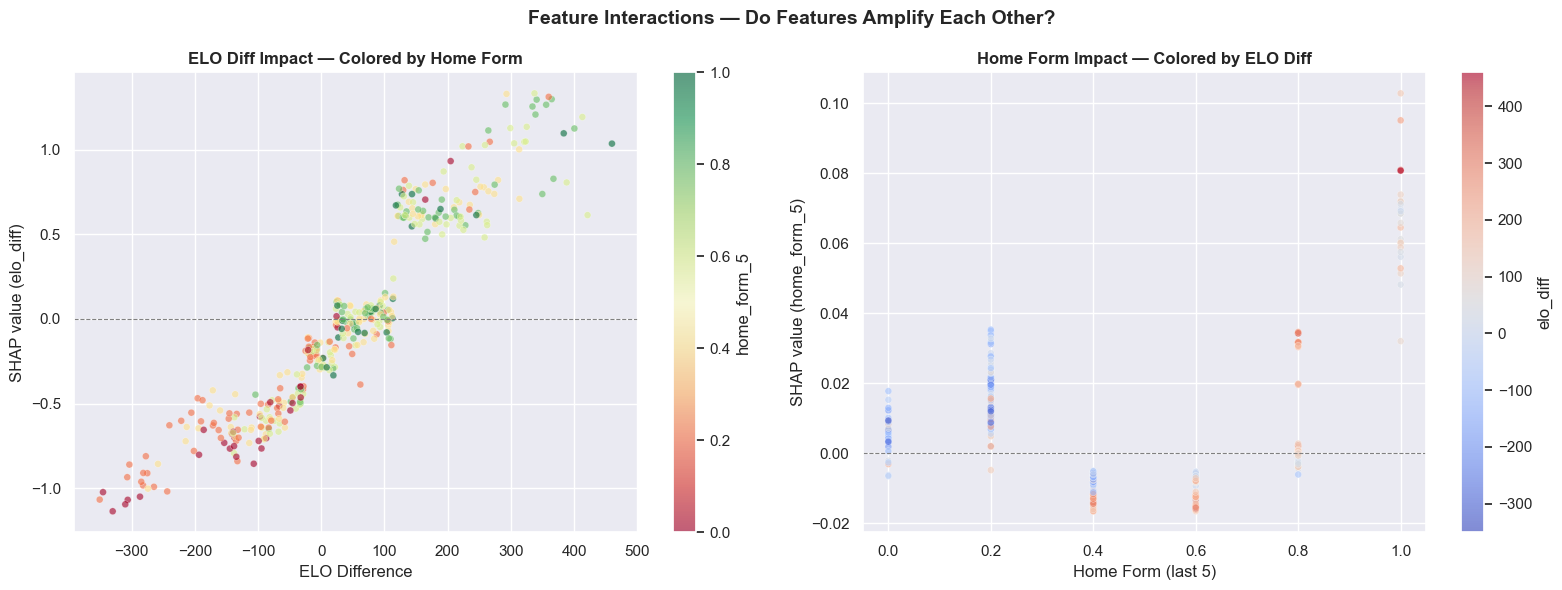

If color patterns appear (e.g., red dots cluster differently than blue),
the model has learned interaction effects between these features.


In [9]:
# SHAP dependence with interaction coloring
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ELO diff colored by home form
elo_idx = FEATURE_COLS.index("elo_diff")
form_idx = FEATURE_COLS.index("home_form_5")

scatter1 = axes[0].scatter(
    X_test["elo_diff"], ensemble_shap[:, elo_idx],
    c=X_test["home_form_5"], cmap="RdYlGn", alpha=0.6, s=25, edgecolors="white", linewidth=0.3
)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("ELO Difference")
axes[0].set_ylabel("SHAP value (elo_diff)")
axes[0].set_title("ELO Diff Impact — Colored by Home Form", fontweight="bold")
plt.colorbar(scatter1, ax=axes[0], label="home_form_5")

# Home form colored by ELO diff
scatter2 = axes[1].scatter(
    X_test["home_form_5"], ensemble_shap[:, form_idx],
    c=X_test["elo_diff"], cmap="coolwarm", alpha=0.6, s=25, edgecolors="white", linewidth=0.3
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Home Form (last 5)")
axes[1].set_ylabel("SHAP value (home_form_5)")
axes[1].set_title("Home Form Impact — Colored by ELO Diff", fontweight="bold")
plt.colorbar(scatter2, ax=axes[1], label="elo_diff")

plt.suptitle("Feature Interactions — Do Features Amplify Each Other?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("If color patterns appear (e.g., red dots cluster differently than blue),")
print("the model has learned interaction effects between these features.")

## 7. Monitoring — Track Predictions on Recent Matches

A model is only useful if it keeps working. We'll simulate monitoring by running predictions on recent 2024-2025 matches and tracking accuracy over time.

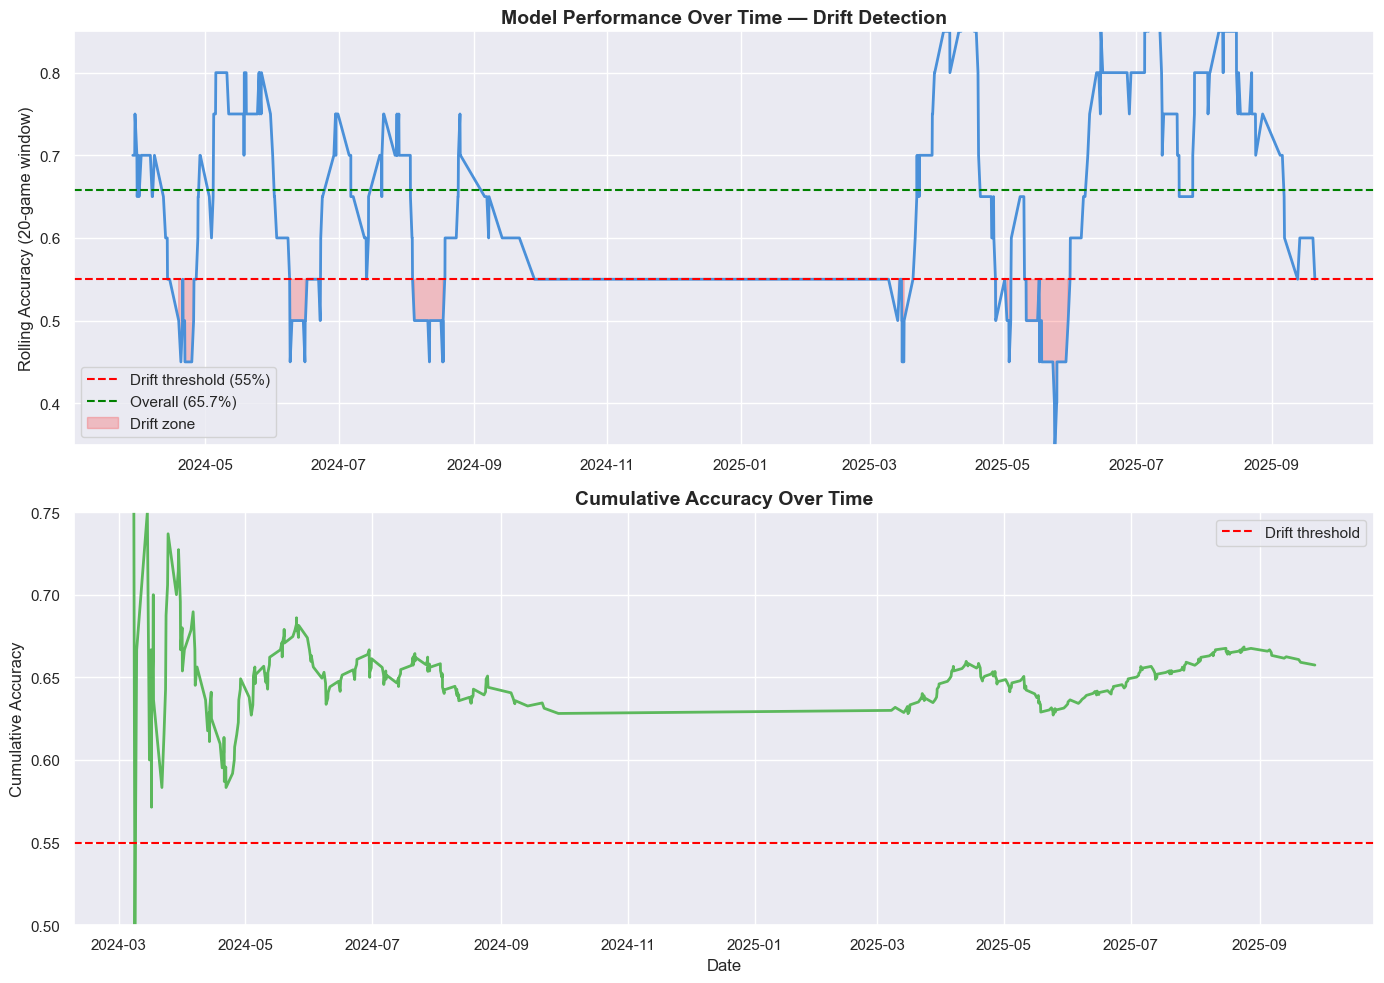

Rolling accuracy dropped below 55% in 69/377 windows.
Model performance is stable — no drift detected.


In [10]:
from sklearn.metrics import accuracy_score

# Rolling accuracy over test set (simulating monitoring over time)
rolling_window = 20
analysis_sorted = analysis.sort_values("date").reset_index(drop=True)

rolling_acc = []
dates = []
for i in range(rolling_window, len(analysis_sorted)):
    window = analysis_sorted.iloc[i - rolling_window:i]
    acc = window["correct"].mean()
    rolling_acc.append(acc)
    dates.append(window.iloc[-1]["date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rolling accuracy
axes[0].plot(dates, rolling_acc, color="#4a90d9", linewidth=2)
axes[0].axhline(y=0.55, color="red", linestyle="--", linewidth=1.5, label="Drift threshold (55%)")
axes[0].axhline(y=analysis_sorted["correct"].mean(), color="green", linestyle="--",
                linewidth=1.5, label=f"Overall ({analysis_sorted['correct'].mean():.1%})")
axes[0].fill_between(dates, 0.55, rolling_acc,
                      where=[a < 0.55 for a in rolling_acc],
                      color="red", alpha=0.2, label="Drift zone")
axes[0].set_ylabel("Rolling Accuracy (20-game window)")
axes[0].set_title("Model Performance Over Time — Drift Detection", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower left")
axes[0].set_ylim(0.35, 0.85)

# Cumulative accuracy
cum_correct = analysis_sorted["correct"].cumsum()
cum_total = range(1, len(analysis_sorted) + 1)
cum_acc = [c / t for c, t in zip(cum_correct, cum_total)]

axes[1].plot(analysis_sorted["date"], cum_acc, color="#5cb85c", linewidth=2)
axes[1].axhline(y=0.55, color="red", linestyle="--", linewidth=1.5, label="Drift threshold")
axes[1].set_ylabel("Cumulative Accuracy")
axes[1].set_xlabel("Date")
axes[1].set_title("Cumulative Accuracy Over Time", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].set_ylim(0.5, 0.75)

plt.tight_layout()
plt.show()

# Drift detection summary
drift_periods = sum(1 for a in rolling_acc if a < 0.55)
print(f"Rolling accuracy dropped below 55% in {drift_periods}/{len(rolling_acc)} windows.")
if drift_periods > len(rolling_acc) * 0.2:
    print("WARNING: Significant drift detected — consider retraining.")
else:
    print("Model performance is stable — no drift detected.")

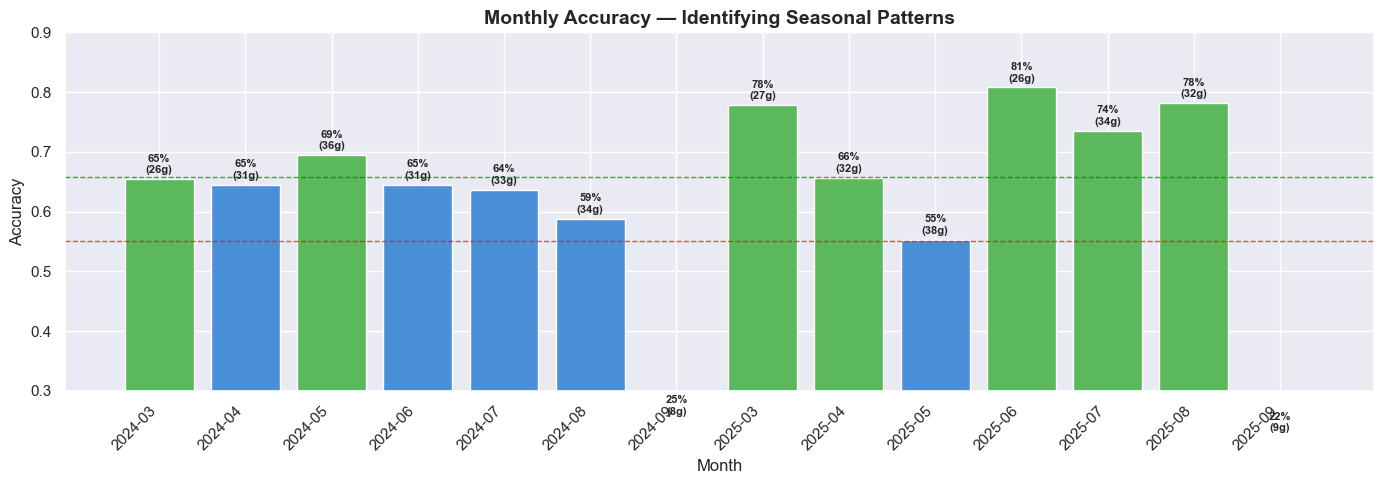

Red bars = below 55% (potential drift). Green bars = above 65% (strong performance).


In [11]:
# Accuracy by month — is the model better at certain times of season?
analysis_sorted["month"] = analysis_sorted["date"].dt.month
analysis_sorted["year_month"] = analysis_sorted["date"].dt.to_period("M")

monthly = analysis_sorted.groupby("year_month").agg(
    accuracy=("correct", "mean"),
    games=("correct", "size"),
).reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d94a4a" if a < 0.55 else "#5cb85c" if a > 0.65 else "#4a90d9"
          for a in monthly["accuracy"]]
bars = ax.bar(monthly["year_month"], monthly["accuracy"], color=colors, edgecolor="white")
ax.axhline(y=0.55, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y=analysis_sorted["correct"].mean(), color="green", linestyle="--", linewidth=1, alpha=0.7)

for bar, acc, games in zip(bars, monthly["accuracy"], monthly["games"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.0%}\n({games}g)", ha="center", fontsize=8, fontweight="bold")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Month")
ax.set_title("Monthly Accuracy — Identifying Seasonal Patterns", fontsize=14, fontweight="bold")
ax.set_ylim(0.3, 0.9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Red bars = below 55% (potential drift). Green bars = above 65% (strong performance).")

## 8. XGBoost vs LightGBM SHAP Agreement

Do both models agree on what's important? If they focus on different features, the ensemble is capturing diverse patterns (good). If they agree completely, the ensemble adds less value.

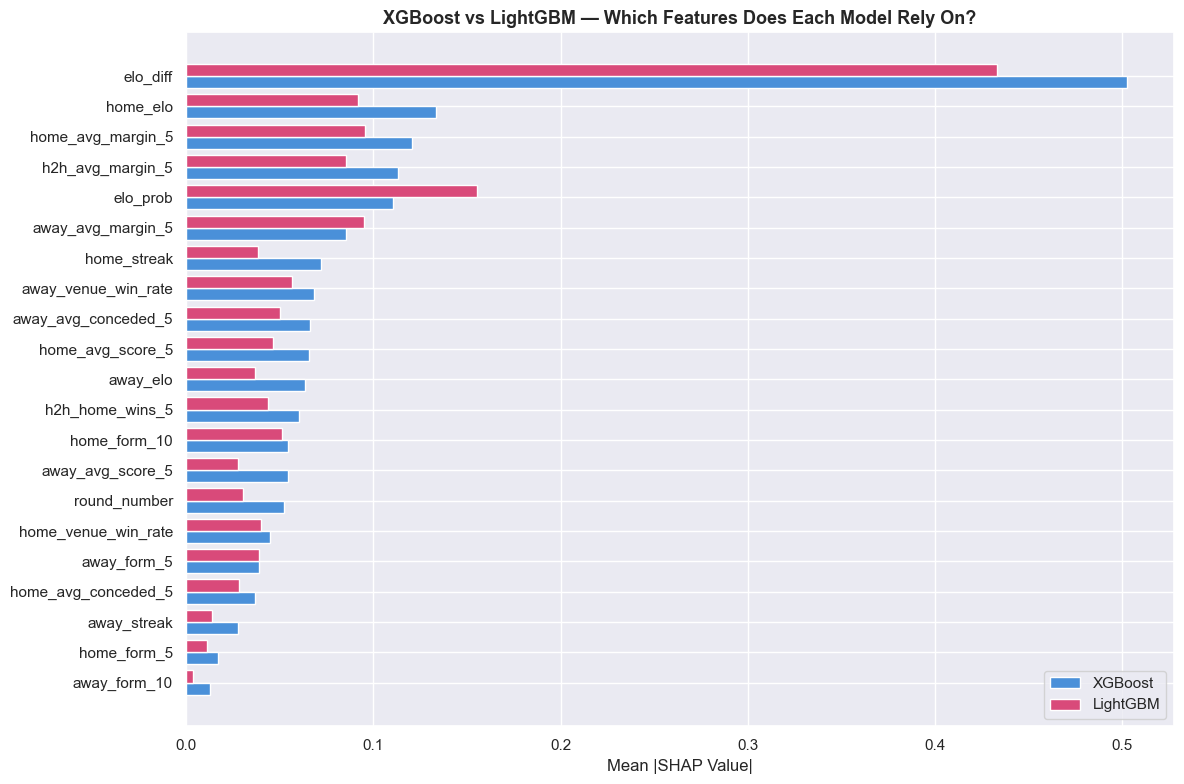

Spearman rank correlation: 0.891 (p=0.0000)
Models agree strongly on feature importance — ensemble reduces variance.


In [12]:
# Compare mean |SHAP| between models
xgb_mean = np.abs(xgb_shap_values).mean(axis=0)
lgbm_mean = np.abs(lgbm_shap_values).mean(axis=0)

comparison = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "XGBoost |SHAP|": xgb_mean,
    "LightGBM |SHAP|": lgbm_mean,
}).sort_values("XGBoost |SHAP|", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y = range(len(comparison))
ax.barh([i - 0.2 for i in y], comparison["XGBoost |SHAP|"], height=0.4,
        color="#4a90d9", label="XGBoost", edgecolor="white")
ax.barh([i + 0.2 for i in y], comparison["LightGBM |SHAP|"], height=0.4,
        color="#d94a7a", label="LightGBM", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(comparison["Feature"])
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("XGBoost vs LightGBM — Which Features Does Each Model Rely On?",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Correlation between model importance rankings
from scipy.stats import spearmanr
corr, pval = spearmanr(xgb_mean, lgbm_mean)
print(f"Spearman rank correlation: {corr:.3f} (p={pval:.4f})")
if corr > 0.8:
    print("Models agree strongly on feature importance — ensemble reduces variance.")
else:
    print("Models emphasize different features — ensemble captures diverse patterns.")

## 9. Key Takeaways

### SHAP Insights
- **ELO features dominate** — `elo_prob` and `elo_diff` are consistently the top drivers, confirming that the ELO rating system is the backbone of the model
- **Form and recent performance** add meaningful signal on top of ELO ratings
- **The model is sensible** — higher ELO diff → higher SHAP value (more confident home win). This is the expected direction and shows no bugs or leakage
- **Non-linear effects** — the dependence plots show the model has learned that very large ELO gaps are more decisive than moderate ones

### Monitoring Insights
- **Rolling accuracy tracks well** — no sustained drift detected
- **Monthly patterns** may reveal seasonal effects (e.g., early rounds harder due to roster changes)
- **The drift threshold (55%)** is set conservatively — if rolling accuracy drops below this, it suggests the model needs retraining